In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd /Users/armandoroqueestrada/Proyecto_Proca/stability

/Users/armandoroqueestrada/Proyecto_Proca/Stability


In [3]:
import Modules.Background as bg
import numpy as np

import matplotlib.pyplot as plt
import Modules.Plot as cplot

In [4]:
cplot.general()

### Background solutions

Since we have scaling freedom, we only need to compute $\sigma_0 = 1$ and derive the rest from this.

\begin{align}
t \to \lambda_*^{-1} t, \quad \vec{x}\to \lambda_*^{-1/2} \vec{x},\quad U\to \lambda_x U, \quad \vec\psi \to \lambda_* \vec\psi
\end{align}

In [5]:
s0val = [1.]  #1 0.1,  0.4532695662510947  0.07685307285680942, 0.4532695662510947

Finding a profile with nodes: [0]
Final precision: U0 = [1.69471091] radius 17.762393210062694


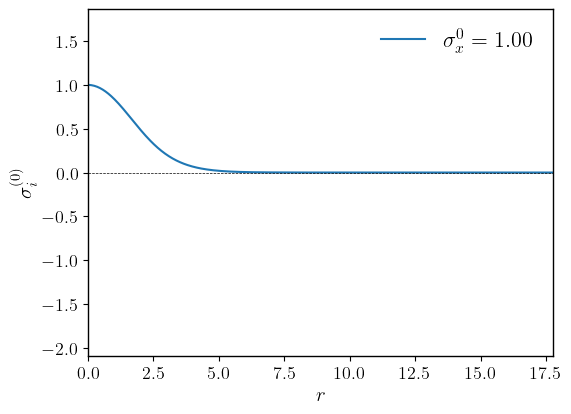

In [17]:
LambT = 0 # autointeracción: 1 (repulsive), 0 (without selinteraction), -1 (attractive)

nx = 0  # node numbers: nx -> nodes of \sigma_x, ny  -> nodes of \sigma_y, ...
nodos = [nx]  # list of node info

p1x = 0  # the first derivative value (p1x), the latter is zero
u1x = 0 # The first derivatives of the x, y, and z effective potential components are all zero.

rmax = 100  # iteration radius

# Range of values used as seed for the effective potential
Uxint = [0.00000012057279119421096, 18]
Uintrs = [Uxint]
numFields = len(Uintrs)

met = 'DOP853'
gamma = 1 # 0 lineal
Rtol = 1e-13 
Atol = 1e-15

datos = []
for p0x in s0val:  # The central amplitude of \sigma_x (p0x) and
    Ini0 = [p0x, p1x, u1x]  # boundary conditions list
    u0Val, rTmax, events = bg.MultFreq_solveG2(Ini0, numFields=numFields, Uintrs=Uintrs, rmax=rmax, LambT=LambT, gamma=gamma, met=met,
                                                nodos=nodos, lim=1e-14, info=False, klim=5000, outval=0, delta=0., Rtol=Rtol, Atol=Atol)

    # plot the result
    U0 = np.zeros(4*numFields)
    U0[:2*numFields] = Ini0[:2*numFields]
    U0[2*numFields+1::2] = Ini0[2*numFields:]
    U0[2*numFields::2] = u0Val
    arg = [numFields, LambT, gamma]

    cplot.plotPerf(U0, rTmax, arg=arg)
    
    #f0, rmax, gamma, LambT, nodes, posNodes, met, Rtol, Atol, u0    
    datos.append([p0x, rTmax, gamma, LambT, nodos, None, met, Rtol, Atol, u0Val])

In [16]:
# datos

Mass values: [9.484549892095593]
Eigenvalues of energy: [-2.433650566111077]


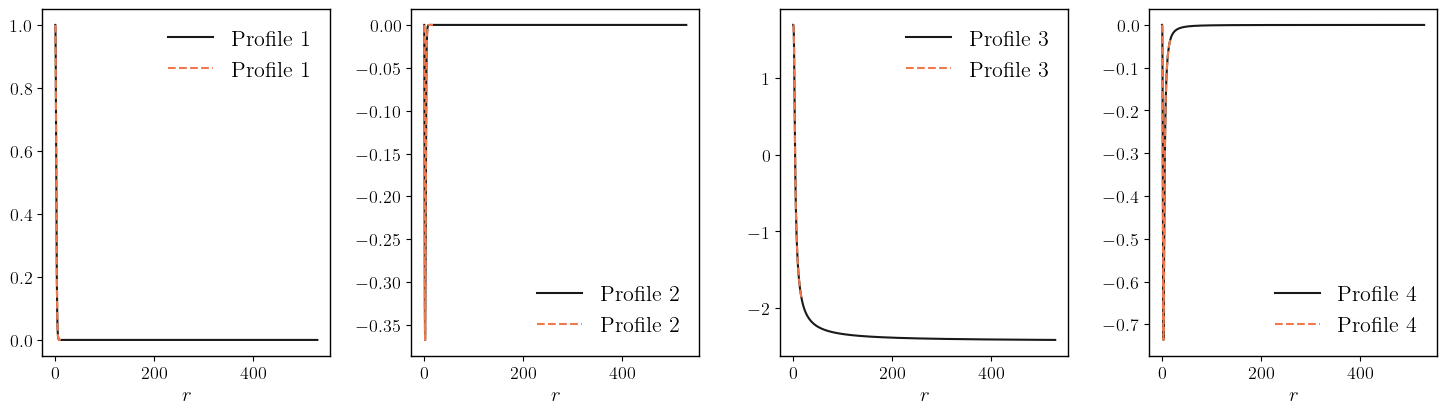

In [18]:
# Extendiendo los perfiles
Ext = 500
Np = 500 #int(2e06)

confidataEx = []
for confi in datos: #
    dataEx = bg.mainExt(confi, mult=False, rmin=0, Nptos=Np, met='DOP853', metExp=1, info=True,
                    Rtol=1e-13, Atol=1e-15, deltaExt=Ext, yscale='linear', xscale='linear', sigfilt=1e-24)  # out [[Ei, rDnew, sDnew, dsDnew, uDnew, duDnew], ..]
    confidataEx.append(dataEx[0])

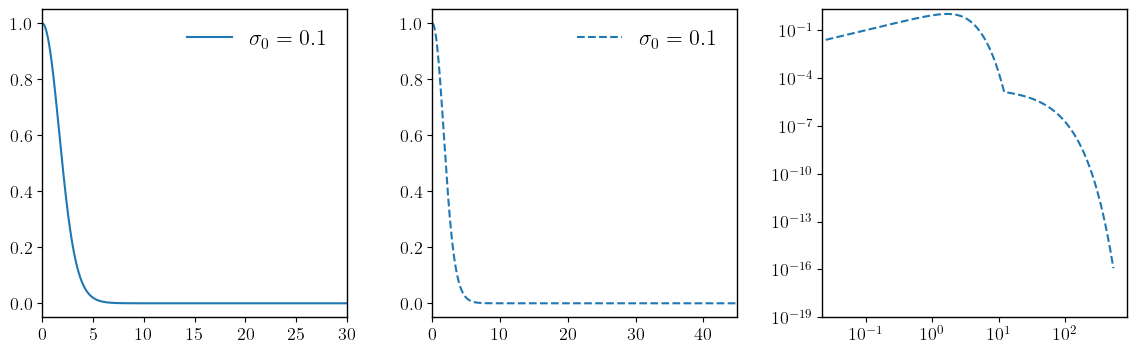

In [19]:
# Test scaling
# [[Ei, rDnew, sDnew, dsDnew, uDnew, duDnew], ..]
Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = confidataEx[0]
# Ei1, rDnew1, sDnew1, dsDnew1, uDnew1, duDnew1 = confidataEx[1]

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(14, 4),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.0, wspace=.28))

ax[0].plot(rDnew, sDnew, label=r'$\sigma_0=0.1$')
# ax[0].plot(rDnew1, sDnew1, label=r'$\sigma_0=1$')
ax[0].legend(frameon=False)
ax[0].set_xlim(0, 30)
ax[0].set_xticks([0, 5, 10, 15, 20, 25, 30])
###########

#cte = (sDnew[0]/sDnew1[0])**(2/3)
#print(cte, (max(rDnew*sDnew))/(max(rDnew1*sDnew1)))
ax[1].plot(rDnew, sDnew, label=r'$\sigma_0=0.1$', ls='--')
#ax[1].plot(rDnew1/np.sqrt(cte), sDnew1*cte**(3/2), lw=1, label=r'$\sigma_0=1*\lambda_*$')
ax[1].legend(frameon=False)
ax[1].set_xlim(0, 45)

####
ax[2].plot(rDnew, np.abs(rDnew*sDnew), label=r'$\sigma_0=0.1$', ls='--')
#ax[2].plot(rDnew1/np.sqrt(cte), np.abs((rDnew1*sDnew1)*cte), lw=1, label=r'$\sigma_0=1*\lambda_*$')
#ax[2].legend(frameon=False)

#ax[2].set_xlim(0, 60)
ax[2].set_ylim(1e-19, 2)
ax[2].set_xscale('log')
ax[2].set_yscale('log')

#ax[1].set_ylim(1e-12, 1)
#ax[0].hlines(1e-28, 0, 1000)

In [20]:
# saving
temp = np.array(confidataEx[0], dtype="object")
np.save("sigma_0_1_rad", temp)

## Cargando perfiles

(0.0, 45.0)

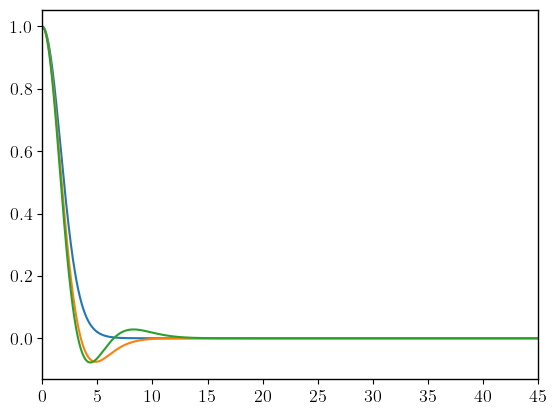

In [24]:
s01 = np.load("sigma_0_1_rad.npy", allow_pickle=True)
s01n1 = np.load("sigma_0_1_radn1.npy", allow_pickle=True)
s01n2 = np.load("sigma_0_1_radn2.npy", allow_pickle=True)

Ei1, rDnew1, sDnew1, dsDnew1, uDnew1, duDnew1 = s01
Ei1n1, rDnew1n1, sDnew1n1, dsDnew1n1, uDnew1n1, duDnew1n1 = s01n1
Ei1n2, rDnew1n2, sDnew1n2, dsDnew1n2, uDnew1n2, duDnew1n2 = s01n2

plt.plot(rDnew1, sDnew1)
plt.plot(rDnew1n1, sDnew1n1)
plt.plot(rDnew1n2, sDnew1n2)
plt.xlim(0, 45)